# House Price Prediction Model

This notebook demonstrates:
1. Data Loading and Preprocessing
2. Exploratory Data Analysis (EDA) with Heatmap, Scatter Plot, and Distribution Plot
3. Model Training using Simple Linear Regression
4. Prediction using Random Forest and XGBoost


In [1]:
# Install necessary libraries if not already installed
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Set plot style
sns.set(style="whitegrid")


In [2]:
# Load the dataset
file_path = 'data/housing.csv'
df = pd.read_csv(file_path)

# Display first few rows
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

# Handle missing values

In [53]:
# 'total_bedrooms' has missing values. We will fill them with the median.
# df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())
df['total_bedrooms'].dropna()
df.isnull().sum()

longitude                  0
latitude                   0
housing_median_age         0
total_rooms                0
total_bedrooms             0
population                 0
households                 0
median_income              0
median_house_value         0
ocean_proximity            0
ocean_proximity_encoded    0
dtype: int64

# Using Label encoder for encoding the categorical data
## Encoding Categorical Data
### 'ocean_proximity' is a categorical column. We can use Label Encoding for simplicity or One-Hot Encoding.

In [54]:
print("\nUnique values in ocean_proximity:", df['ocean_proximity'].unique())
# so here we have to make the this cateroical value to numeric value using label encoder


Unique values in ocean_proximity: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [55]:
# Using Label Encoder
le = LabelEncoder()
df['ocean_proximity_encoded'] = le.fit_transform(df['ocean_proximity'])

# Drop the original categorical column for correlation analysis and modeling
df_model = df.drop('ocean_proximity', axis=1)

print("\nData after preprocessing:")
df_model.head()



Data after preprocessing:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


## 1. Heatmap using Correlation Matrix


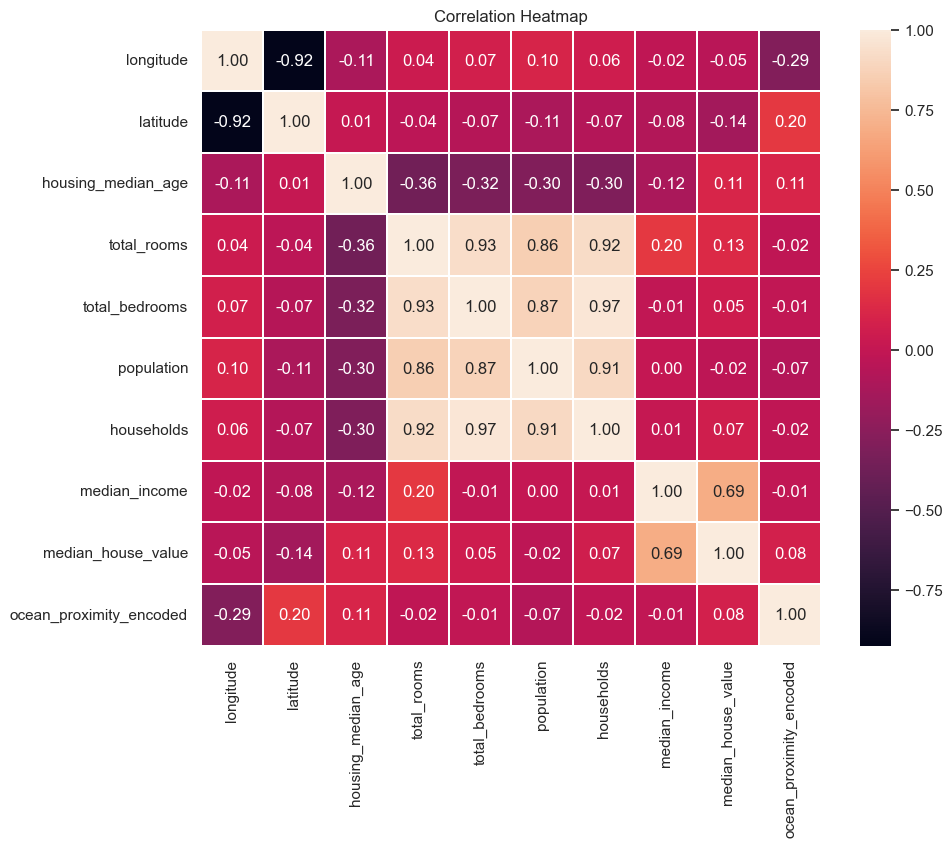

In [56]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_model.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", linewidths=0.2)
plt.title('Correlation Heatmap')
plt.show()


## 2. Scatter Graph

Visualizing the relationship between Median Income and Median House Value (usually the strongest correlation).


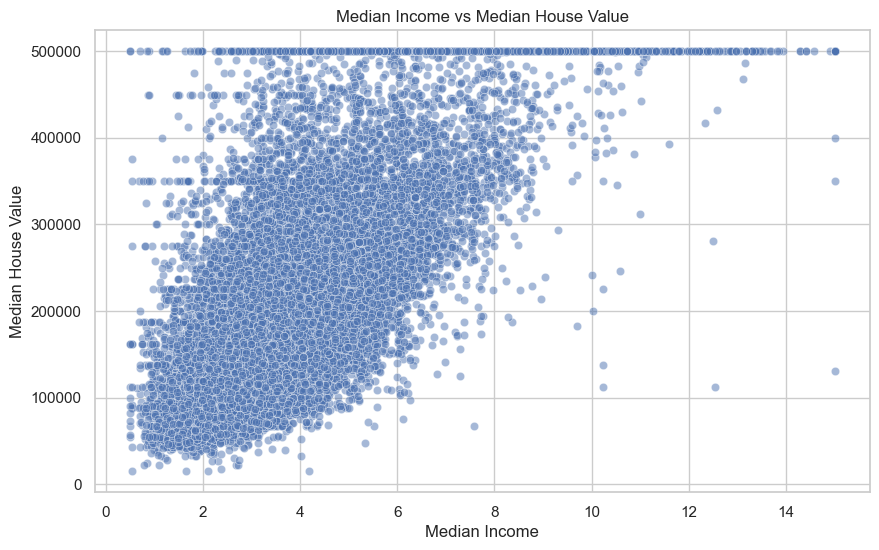

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.5)
plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()


## 3. Distribution Graph

Checking the distribution of the target variable: Median House Value.


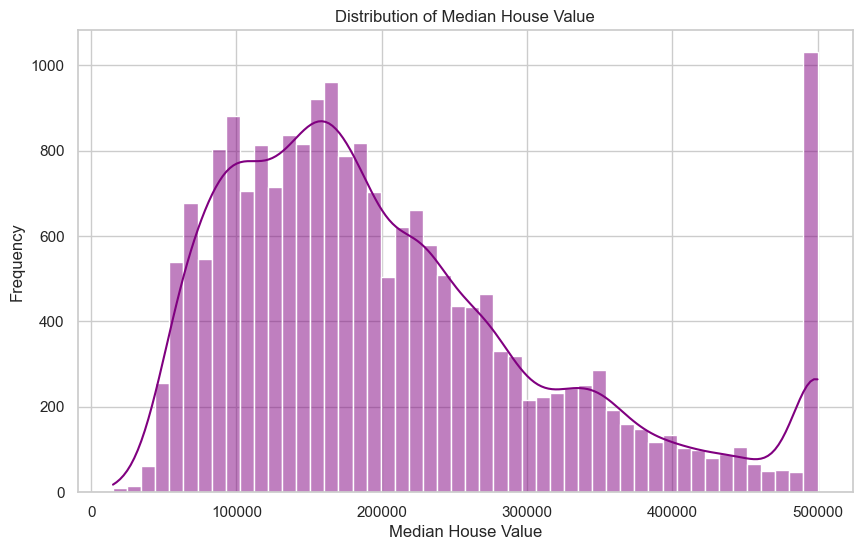

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], kde=True, bins=50, color='purple')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()


## Data Splitting


In [58]:
# Define features (X) and target (y)
X = df_model.drop('median_house_value', axis=1)
y = df_model['median_house_value']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (16512, 9)
Test set shape: (4128, 9)


## 1. Simple Linear Regression

Using Linear Regression for training the model.


In [59]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"RMSE: {rmse_lr}")
print(f"R2 Score: {r2_lr}")


Linear Regression Results:
RMSE: 71147.87146118373
R2 Score: 0.6137068886499537


## 2. Random Forest Regression

Using Random Forest for prediction.


In [60]:
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"RMSE: {rmse_rf}")
print(f"R2 Score: {r2_rf}")


Random Forest Results:
RMSE: 50231.07677846623
R2 Score: 0.8074523972118022


## 3. XGBoost Regression

Using XGBoost for prediction.


In [61]:
# Initialize and train the model
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"RMSE: {rmse_xgb}")
print(f"R2 Score: {r2_xgb}")


XGBoost Results:
RMSE: 49052.45114129142
R2 Score: 0.8163822895811657


## Model Comparison


               Model          RMSE  R2 Score
2            XGBoost  49052.451141  0.816382
1      Random Forest  50231.076778  0.807452
0  Linear Regression  71147.871461  0.613707


C:\Users\Krithik Naidu\AppData\Local\Temp\ipykernel_21792\2788152744.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=models, palette='viridis')


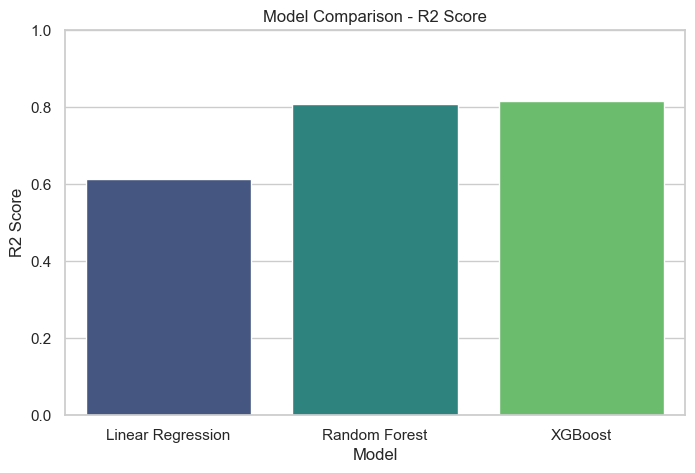

In [33]:
models = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R2 Score': [r2_lr, r2_rf, r2_xgb]
})

print(models.sort_values(by='R2 Score', ascending=False))

# Bar plot of R2 Scores
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R2 Score', data=models, palette='viridis')
plt.title('Model Comparison - R2 Score')
plt.ylim(0, 1)
plt.show()
